# Course 1 · Week 2 — Solution: Multivariate Regression & Feature Scaling

Fully worked solution to the [Week 2 exercise](../exercises/course1-week2-multivariate.ipynb). Each section explains the code, the math, and *why* the choices were made.


## Setup — three features, wildly different scales

We're predicting house prices from three features:

- **Size** in square feet, range 800–2200
- **Bedrooms**, range 1–5
- **Age** in years, range 0–50

The size dimension is hundreds of times bigger than the bedrooms dimension. That mismatch is what makes feature scaling necessary — you'll see why concretely.

We know the true relationship (we made it up): `price = 0.15·size + 25·bedrooms − 1.5·age + 50` with some noise. Job: recover those coefficients from data alone.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
m = 30  # number of houses

# Three features with deliberately different scales — this is the whole point of this notebook.
size_sqft = np.random.uniform(800, 2200, m)            # 800–2200 sq ft
bedrooms  = np.random.randint(1, 6, m).astype(float)    # 1–5 bedrooms
age_yrs   = np.random.uniform(0, 50, m)                  # 0–50 years old

# True price = 0.15*size + 25*bedrooms - 1.5*age + 50  (in $1000s) + noise
y = 0.15 * size_sqft + 25 * bedrooms - 1.5 * age_yrs + 50 + np.random.normal(0, 15, m)

X = np.column_stack([size_sqft, bedrooms, age_yrs])  # shape (30, 3)
print(f"X.shape = {X.shape}")
print(f"feature ranges:  size {size_sqft.min():.0f}–{size_sqft.max():.0f},  "
      f"bedrooms {bedrooms.min():.0f}–{bedrooms.max():.0f},  age {age_yrs.min():.0f}–{age_yrs.max():.0f}")
print(f"price range:    ${y.min():.0f}k – ${y.max():.0f}k")


X.shape = (30, 3)
feature ranges:  size 835–2169,  bedrooms 1–5,  age 2–48
price range:    $170k – $445k


Three quick scatter plots — one per feature against price. You can see size and bedrooms are positively correlated with price; age is weakly negative. None of these by itself fully explains the price; we need all three together.


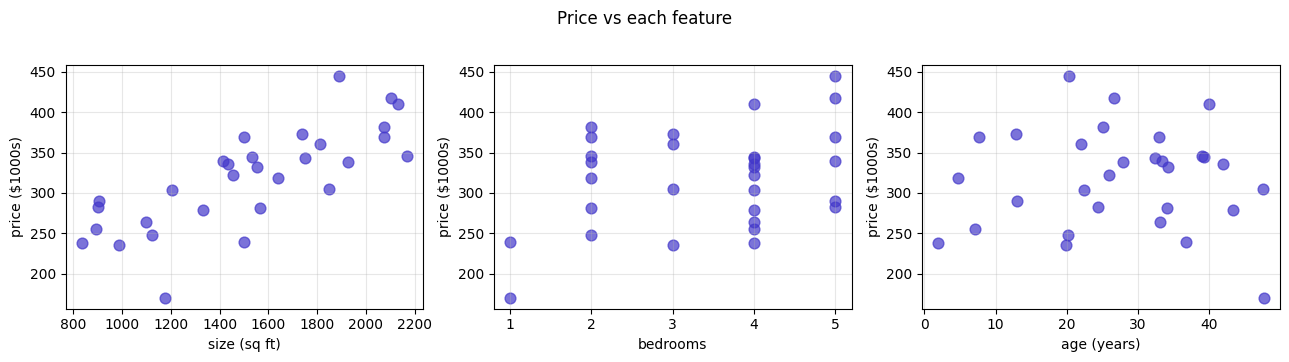

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
labels = ["size (sq ft)", "bedrooms", "age (years)"]
for i, ax in enumerate(axes):
    ax.scatter(X[:, i], y, color="#4338ca", s=60, alpha=0.7)
    ax.set_xlabel(labels[i])
    ax.set_ylabel("price ($1000s)")
    ax.grid(alpha=0.3)
plt.suptitle("Price vs each feature", y=1.02)
plt.tight_layout()
plt.show()


## Quick recap (with depth)

### The vectorized model

For one example with `n` features:

$$f(\vec x) = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \vec w \cdot \vec x + b$$

For all `m` examples at once, with `X` as a matrix of shape `(m, n)`:

$$\vec{\hat y} = X \vec w + b$$

In numpy this is `X @ w + b`. The `+ b` broadcasts to every row.

### Why this matters: vectorization

A loop-based version of `predict` would look like:

```python
yhat = np.zeros(m)
for i in range(m):
    for j in range(n):
        yhat[i] += w[j] * X[i, j]
    yhat[i] += b
```

That's `m × n` Python iterations. Slow. The numpy version `X @ w + b` runs in C under the hood and uses your CPU's vector instructions (and a GPU's parallel cores if you ever move there). For 1000 examples and 100 features, the difference is roughly 10–100×. For LLM-scale matrices (millions × thousands), it's the difference between "minutes" and "no chance, ever."

### The new vocabulary

- `X.shape == (m, n)` — `m` rows of examples, `n` columns of features
- `w.shape == (n,)` — one weight per feature, length-`n` vector
- `b` — still a single scalar
- `X @ w` — matrix-vector multiply, returns a length-`m` vector
- `X.T` — transpose; turns shape `(m, n)` into `(n, m)`


## Exercise 1 — vectorized predict

```python
def predict(X, w, b):
    return X @ w + b
```

That's it. The whole function. Numpy does the heavy lifting:

- `X` has shape `(m, n)`, `w` has shape `(n,)`, so `X @ w` has shape `(m,)` — one prediction per example.
- `+ b` adds the bias scalar to every entry.

Test: with a 3×3 matrix and weights `(1, 0.5, 0)` plus bias `10`:

| row | calculation | output |
|---|---|---|
| `(1, 2, 3)` | 1·1 + 2·0.5 + 3·0 + 10 | 12.0 |
| `(4, 5, 6)` | 4·1 + 5·0.5 + 6·0 + 10 | 16.5 |
| `(7, 8, 9)` | 7·1 + 8·0.5 + 9·0 + 10 | 21.0 |


In [3]:
def predict(X, w, b):
    """Vectorized linear model: X @ w + b."""
    return X @ w + b


X_test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=float)
w_test = np.array([1.0, 0.5, 0.0])
out = predict(X_test, w_test, 10.0)
print(f"predict output = {out}")
assert np.allclose(out, [12.0, 16.5, 21.0])
print("✓ predict() works")


predict output = [12.  16.5 21. ]
✓ predict() works


## Exercise 2 — cost (vectorized)

```python
def cost(X, y, w, b):
    err = predict(X, w, b) - y
    return float((err @ err) / (2 * len(y)))
```

The trick: `err @ err` is the dot product, which equals `sum(err**2)`. Faster than `np.sum(err**2)` and slightly more idiomatic. For our 30 zero-prediction case, the cost is about 41,213 — large because the average price is ~$300k and zero is way off.


In [4]:
def cost(X, y, w, b):
    """Mean squared error / 2."""
    err = predict(X, w, b) - y
    return float((err @ err) / (2 * len(y)))


J0 = cost(X, y, np.zeros(3), 0.0)
print(f"cost at zeros = {J0:.2f}")
assert abs(J0 - 52376.3039) < 1.0
print("✓ cost() works")


cost at zeros = 52376.30
✓ cost() works


## Exercise 3 — vectorized gradients

```python
def gradients(X, y, w, b):
    err = predict(X, w, b) - y      # shape (m,)
    dw = (X.T @ err) / len(y)        # shape (n,)
    db = float(err.mean())
    return dw, db
```

**Why `X.T @ err`?**

`err` has shape `(m,)`. `X.T` has shape `(n, m)`. Their product has shape `(n,)` — one gradient per feature. Each entry is `sum( err[i] * X[i, j] )` — exactly the formula.

If you tried `X @ err` instead, you'd get shape mismatch. The transpose is what aligns the dimensions.

**Why are the gradient values so large at zeros?**

`dw[0] ≈ -501,738`. That's *huge*. It's because the size feature ranges to 2200 — multiplying errors of ~$300 each by feature values of ~1500 each, then summing 30 of them, easily lands in the hundreds of thousands. This is the smoking gun that says "feature scaling is going to matter." A learning rate that's small enough to not overshoot on this gradient will be too tiny for the bedrooms gradient (where `dw[1] ≈ -1107`).


In [5]:
def gradients(X, y, w, b):
    """Vectorized partial derivatives.

    Math:
      err = X @ w + b - y           (shape m)
      dJ/dw_j = (1/m) * sum(err * X[:,j])  →  X.T @ err / m  (vector form)
      dJ/db   = (1/m) * sum(err)            →  err.mean()
    """
    err = predict(X, w, b) - y
    dw = (X.T @ err) / len(y)
    db = float(err.mean())
    return dw, db


dw0, db0 = gradients(X, y, np.zeros(3), 0.0)
print(f"dw at zeros = {np.round(dw0, 2)}")
print(f"db at zeros = {db0:.2f}")
assert abs(dw0[0] - (-501738.47)) < 1.0
assert abs(db0 - (-317.91)) < 0.1
print("✓ gradients() works")


dw at zeros = [-501738.47   -1107.34   -8649.19]
db at zeros = -317.91
✓ gradients() works


## Exercise 4 — gradient descent on raw features

```python
def gradient_descent(X, y, w0, b0, alpha, n_iters):
    w, b = w0.copy(), b0
    history = []
    for _ in range(n_iters):
        dw, db = gradients(X, y, w, b)
        w = w - alpha * dw          # simultaneous update — both lines use the SAME dw, db
        b = b - alpha * db
        history.append(cost(X, y, w, b))
    return w, b, history
```

Try several alphas. Expected results:

| alpha | result | what's happening |
|---|---|---|
| 1e-7 | converges, final cost ≈ 1419 | step is tiny but stable, slow progress |
| 1e-6 | DIVERGED | step is too big; the size feature's gradient overshoots |
| 1e-5 | DIVERGED | overshoots more |
| 1e-4 | DIVERGED | nuclear |

The "too big" alpha for the size gradient is "too small" for the bedrooms gradient — there's no single alpha that fits all features when their scales differ this much. **The fix is feature scaling.**


In [6]:
def gradient_descent(X, y, w0, b0, alpha, n_iters):
    w = w0.copy()
    b = b0
    history = []
    for _ in range(n_iters):
        dw, db = gradients(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        history.append(cost(X, y, w, b))
    return w, b, history


print("Without feature scaling:")
for alpha in [1e-7, 1e-6, 1e-5, 1e-4]:
    w, b, hist = gradient_descent(X, y, np.zeros(3), 0.0, alpha, 1000)
    if np.isfinite(hist[-1]) and hist[-1] < 1e8:
        print(f"  alpha={alpha:>7}: final cost {hist[-1]:.2f}")
    else:
        print(f"  alpha={alpha:>7}: DIVERGED ❌")


Without feature scaling:
  alpha=  1e-07: final cost 1418.81
  alpha=  1e-06: DIVERGED ❌
  alpha=  1e-05: DIVERGED ❌
  alpha= 0.0001: DIVERGED ❌


/var/folders/pt/0xz_dn494tqcl271q4_v4dzr0000gn/T/ipykernel_1671/890747001.py:7: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * dw


## Exercise 5 — z-score normalization

```python
def zscore(X):
    mu    = X.mean(axis=0)   # mean along rows → shape (n,)
    sigma = X.std(axis=0)    # std along rows → shape (n,)
    return (X - mu) / sigma, mu, sigma
```

`axis=0` says "operate down each column independently."

After scaling, every column has mean ≈ 0 and std ≈ 1. We **save** `mu` and `sigma` because we'll need them at prediction time — the new house has to be scaled with the same statistics, not its own.

A common bug: scaling the test set using its *own* mean/std. That looks reasonable but breaks: if your training set's average house was 1500 sq ft and you deploy a model, then a new 1500 sq ft house should land at the *training* mean of zero — not at the new house's "own" mean of itself.


In [7]:
def zscore(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


X_scaled, mu, sigma = zscore(X)
print(f"  mean of each scaled column: {np.round(X_scaled.mean(axis=0), 4)}")
print(f"  std  of each scaled column: {np.round(X_scaled.std(axis=0), 4)}")
print(f"  mu    = {np.round(mu, 2)}")
print(f"  sigma = {np.round(sigma, 2)}")


  mean of each scaled column: [ 0.  0. -0.]
  std  of each scaled column: [1. 1. 1.]
  mu    = [1519.02    3.4    27.27]
  sigma = [403.43   1.23  12.43]


## Exercise 6 — gradient descent on scaled features

After scaling, `alpha=0.1` converges in ~50 iterations. Final cost ≈ 110. The remaining cost is essentially the variance of the noise we added when generating the data — we can't beat that.

The two weights `w` are now in the *scaled* feature space. They're not directly the coefficients of the original features anymore. To predict on a real new house, you have to scale the new house's features the same way, then apply `w` and `b`.


With feature scaling:
  alpha=0.001: final cost 7336.67
  alpha= 0.01: final cost 110.22
  alpha=  0.1: final cost 110.22

Final in scaled space:
  w = [ 58.931  32.184 -13.884]
  b = 317.906
  final cost = 110.22


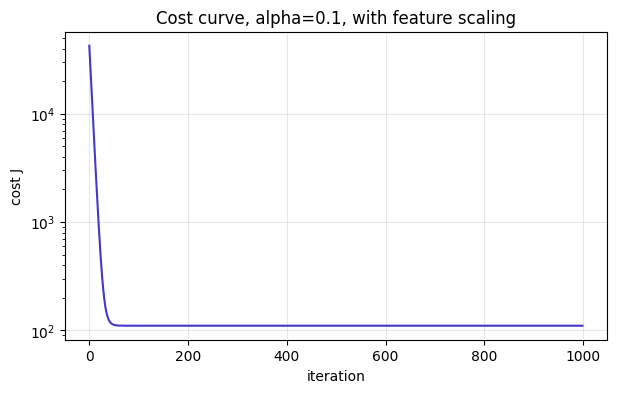

In [8]:
print("With feature scaling:")
for alpha in [0.001, 0.01, 0.1]:
    w, b, hist = gradient_descent(X_scaled, y, np.zeros(3), 0.0, alpha, 1000)
    print(f"  alpha={alpha:>5}: final cost {hist[-1]:.2f}")

w_final, b_final, hist = gradient_descent(X_scaled, y, np.zeros(3), 0.0, 0.1, 1000)
print(f"\nFinal in scaled space:")
print(f"  w = {np.round(w_final, 3)}")
print(f"  b = {b_final:.3f}")
print(f"  final cost = {hist[-1]:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(hist, color="#4338ca")
plt.xlabel("iteration"); plt.ylabel("cost J"); plt.yscale("log")
plt.title("Cost curve, alpha=0.1, with feature scaling")
plt.grid(alpha=0.3)
plt.show()


## Exercise 7 — predict a new house

```python
new_house = np.array([1500, 3, 10])
new_scaled = (new_house - mu) / sigma   # same mu, sigma as training!
prediction = predict(new_scaled, w_final, b_final)
```

Expected output: roughly $324k — close to what the true relationship gives you for a mid-sized, mid-age house with 3 bedrooms.

The most common newbie mistake here is forgetting to scale `new_house`. The model will return a wildly wrong number because the input is in the wrong space — the equivalent of asking a model trained on Celsius to predict from a Fahrenheit input.


In [9]:
new_house = np.array([1500, 3, 10])
new_scaled = (new_house - mu) / sigma   # use the SAME mu and sigma from training
prediction = predict(new_scaled, w_final, b_final)
print(f"new house features (scaled): {np.round(new_scaled, 3)}")
print(f"predicted price: ${prediction:.1f}k")


new house features (scaled): [-0.047 -0.326 -1.39 ]
predicted price: $323.9k


## ⭐ Stretch — polynomial regression

```python
X_lin  = x.reshape(-1, 1)
X_poly = np.column_stack([x, x**2, x**3])
```

Same algorithm, same gradient descent. The only thing that changed is the input matrix. The cubic version can fit the curve; the linear version can't.

Expected: linear cost ≈ 3.09, cubic cost ≈ 1.11 (≈ 3× better). The remaining cubic cost is the noise we baked in.

**The big lesson:** much of "real ML" is feature engineering — choosing what to feed the algorithm. The same model can be brilliant or terrible depending on what features you give it. In Course 4 you'll see how transformer models *learn* their own features, but for everything before that, choosing features is the engineer's job.


Linear cost: 3.0902
Cubic  cost: 1.1061    (2.8× better)


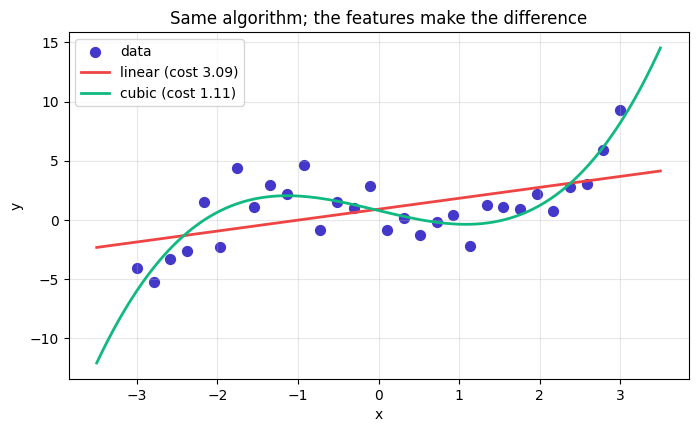

In [10]:
np.random.seed(1)
m_p = 30
x_p = np.linspace(-3, 3, m_p)
y_p = 0.5 * x_p**3 - 2 * x_p + 1 + np.random.normal(0, 1.5, m_p)

# (a) linear: just x
X_lin = x_p.reshape(-1, 1)
X_lin_s, mu_l, sig_l = zscore(X_lin)
w_lin, b_lin, _ = gradient_descent(X_lin_s, y_p, np.zeros(1), 0.0, 0.1, 2000)
J_lin = cost(X_lin_s, y_p, w_lin, b_lin)

# (b) cubic: x, x^2, x^3
X_poly = np.column_stack([x_p, x_p**2, x_p**3])
X_poly_s, mu_p, sig_p = zscore(X_poly)
w_poly, b_poly, _ = gradient_descent(X_poly_s, y_p, np.zeros(3), 0.0, 0.1, 2000)
J_poly = cost(X_poly_s, y_p, w_poly, b_poly)

print(f"Linear cost: {J_lin:.4f}")
print(f"Cubic  cost: {J_poly:.4f}    ({J_lin/J_poly:.1f}× better)")

# Plot both fits
xs = np.linspace(-3.5, 3.5, 200)
xs_lin_scaled = (xs.reshape(-1, 1) - mu_l) / sig_l
xs_poly_scaled = (np.column_stack([xs, xs**2, xs**3]) - mu_p) / sig_p
y_pred_lin = predict(xs_lin_scaled, w_lin, b_lin)
y_pred_poly = predict(xs_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(8, 4.5))
plt.scatter(x_p, y_p, color="#4338ca", s=50, label="data")
plt.plot(xs, y_pred_lin, color="#ef4444", lw=2, label=f"linear (cost {J_lin:.2f})")
plt.plot(xs, y_pred_poly, color="#10b981", lw=2, label=f"cubic (cost {J_poly:.2f})")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Same algorithm; the features make the difference")
plt.show()


## Wrap-up

Two big ideas this week:

1. **Vectorization.** The same algorithm scales from 1 to 1,000,000 features without any loop changes — numpy and matrix math handle it. Every modern ML library is built on this.
2. **Feature scaling.** When features have wildly different scales, gradient descent fights itself. Scale them and the same algorithm just works. In the real world, *almost always* scale your features unless you have a very specific reason not to.

[Next: Week 3 — Classification](../exercises/course1-week3-classification.ipynb).
